## Advanced Python: Applied Machine Learning Techniques
### Day 2: Vectorizing Data with `numpy` and `torch.tensor`

##### Planned Topics
  - `numpy` array vs `torch.tensor`
  - Creating numpy arrays and pytorch tensors
  - An overview on numpy and torch datatypes
  - Conversion between `numpy` arrays and PyTorch `tensor`
  - Configuring GPU acceleration in PyTorch tensors
  - Slicing and Broadcasting operations
  - Vectorization and Filtering operations
  - Demo: Implementing activation functions manually
     - TanH
     - Sigmoid
     - ReLU and LeakyReLU
     - Softmax
  - Applying `numpy` concepts in Image manipulation


## Numpy

Numpy is the core library for scientific computing in Python. It provides a high-performance multidimensional array object, and tools for working with these arrays. 

Numpy arrays are efficient representation of homogenous numerical arrays in contiguous memory location that allow fast vectorization and with support for math and complex matrix operations.

Numpy arrays by default are not GPU optimized / parallelized - so vectorization can be slower, but they support wide variety of features.
For faster numpy compatible arrays, you can choose between `pytorch.tensor`, `jax.numpy`, `CuPy` and many others

In [1]:
import numpy as np

a = np.array([11, 22, 33, 44, 55, 66, 77, 88, 99])

a + 1

array([ 12,  23,  34,  45,  56,  67,  78,  89, 100])

#### Setting up conda environment for numpy and pytorch
```
conda create -n apaimlt \
      conda-forge::pytorch torchvision torchaudio \
      numpy matplotlib seaborn scipy scikit-learn \
      pandas ipython jupyter ipywidgets ipykernel tqdm timm
```

To use Numpy, we first need to import the `numpy` package:

In [2]:
import numpy as np
import torch

Getting information about numpy

In [3]:
print(np.__version__)
print(torch.__version__)

2.4.4
2.9.1


In [4]:
print(np.show_config())

Build Dependencies:
  blas:
    detection method: pkgconfig
    found: true
    include directory: /opt/anaconda3/envs/2026_Apr16/include
    lib directory: /opt/anaconda3/envs/2026_Apr16/lib
    name: openblas
    openblas configuration: USE_64BITINT=0 DYNAMIC_ARCH=1 DYNAMIC_OLDER= NO_CBLAS=
      NO_LAPACK=0 NO_LAPACKE= NO_AFFINITY=1 USE_OPENMP=0 VORTEX MAX_THREADS=128
    pc file directory: /opt/anaconda3/envs/2026_Apr16/lib/pkgconfig
    version: 0.3.31
  lapack:
    detection method: pkgconfig
    found: true
    include directory: /opt/anaconda3/envs/2026_Apr16/include
    lib directory: /opt/anaconda3/envs/2026_Apr16/lib
    name: openblas
    openblas configuration: USE_64BITINT=0 DYNAMIC_ARCH=1 DYNAMIC_OLDER= NO_CBLAS=
      NO_LAPACK=0 NO_LAPACKE= NO_AFFINITY=1 USE_OPENMP=0 VORTEX MAX_THREADS=128
    pc file directory: /opt/anaconda3/envs/2026_Apr16/lib/pkgconfig
    version: 0.3.31
Compilers:
  c:
    args: -ftree-vectorize, -fPIC, -fstack-protector-strong, -O2, -pipe, -isys

Get configuration of pytorch

In [10]:
print(torch.__config__.parallel_info())

ATen/Parallel:
	at::get_num_threads() : 8
	at::get_num_interop_threads() : 12
OpenMP 202011
	omp_get_max_threads() : 8
MKLDNN not found
std::thread::hardware_concurrency() : 12
Environment variables:
	OMP_NUM_THREADS : [not set]
ATen parallel backend: OpenMP



In [5]:
print(torch.__config__.show())

PyTorch built with:
  - GCC 4.2
  - C++ Version: 201703
  - clang 20.1.8
  - OpenMP 202011
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: DEFAULT
  - Build settings: BLAS_INFO=open, BUILD_TYPE=Release, COMMIT_SHA=Unknown, CXX_COMPILER=/Users/ec2-user/croot/libtorch_1774862146849/_build_env/bin/arm64-apple-darwin20.0.0-clang++, CXX_FLAGS=-ftree-vectorize -fPIC -fstack-protector-strong -O2 -pipe -stdlib=libc++  -fmessage-length=0 -isystem /Users/ec2-user/croot/libtorch_1774862146849/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_pla/include -fdebug-prefix-map=/Users/ec2-user/croot/libtorch_1774862146849/work=/usr/local/src/conda/libtorch-2.9.1 -fdebug-prefix-map=/Users/ec2-user/croot/libtorch_1774862146849/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_

### Arrays

A numpy array is a grid of values, all of the same type, and is indexed by a tuple of nonnegative integers. The number of dimensions is the rank of the array; the shape of an array is a tuple of integers giving the size of the array along each dimension.

We can initialize numpy arrays from nested Python lists, and access elements using square brackets:

In [11]:
a = np.array([[10, 20, 30], [40, 50, 60]])
print(a, type(a))
print(a[1][1], a[1, 1])
print(a[1])

[[10 20 30]
 [40 50 60]] <class 'numpy.ndarray'>
50 50
[40 50 60]


#### Interesting attributes of numpy arrays

In [ ]:
a = np.array([[10, 20, 30], [40, 50, 60], [70, 80, 90], [100, 110, 120]])
print(a, type(a))

In [ ]:
li = [[10, 20, 30, 40, 50], [60, 70, 80, 90, 100], [110, 120, 130, 140, 150]]
len(li)
a = np.array(li)
a[1, 3]

In [14]:
a = np.array([[10, 20, 30, 40], [50, 60, 70, 80], [90, 100, 110, 120]], dtype=np.int32)
print(a)
print(len(a))     # number of rows
print(len(a[0]))  # number of columns
print()
print(f"{a.size=}")     # total number of elements
print(f"{a.shape=}")    # dimensions of the array
print(f"{a.ndim=}")     # number of dimensions
print(f"{a.strides=}")  # bytes to step in each dimension
print(f"{a.itemsize=}") # size of each element
print(f"{a.nbytes=}")   # total bytes consumed by the array
print(f"{a.dtype=}")    # data type of the array

[[ 10  20  30  40]
 [ 50  60  70  80]
 [ 90 100 110 120]]
3
4

a.size=12
a.shape=(3, 4)
a.ndim=2
a.strides=(16, 4)
a.itemsize=4
a.nbytes=48
a.dtype=dtype('int32')


#### Creating pytorch tensors (equivalent to numpy arrays)

In [17]:
a = np.array([[10, 20, 30], [40, 50, 60]])
print(a, type(a))
print(a[1][1], a[1, 1], type(a[1, 1]))
print(a[1])
print(a.dtype)

[[10 20 30]
 [40 50 60]] <class 'numpy.ndarray'>
50 50 <class 'numpy.int64'>
[40 50 60]
int64


In [20]:
t = torch.tensor([[10, 20, 30], [40, 50, 60]])
print(t, type(t))
print(t[1][1], t[1, 1])
print(t[1])
print(t.dtype)

v = t[1, 1]
print(f"{v=}, {v.dtype=}, {type(v)=}, {v.item()=}, {type(v.item())=}")

tensor([[10, 20, 30],
        [40, 50, 60]]) <class 'torch.Tensor'>
tensor(50) tensor(50)
tensor([40, 50, 60])
torch.int64
v=tensor(50), v.dtype=torch.int64, type(v)=<class 'torch.Tensor'>, v.item()=50, type(v.item())=<class 'int'>


In [ ]:
a = np.array([[10, 20, 30, 40], [50, 60, 70, 80], [90, 100, 110, 120]], dtype=np.int32)
print(a)
print(len(a))     # number of rows
print(len(a[0]))  # number of columns
print()
print(f"{a.size=}")     # total number of elements
print(f"{a.shape=}")    # dimensions of the array
print(f"{a.ndim=}")     # number of dimensions
print(f"{a.strides=}")  # bytes to step in each dimension
print(f"{a.itemsize=}") # size of each element
print(f"{a.nbytes=}")   # total bytes consumed by the array
print(f"{a.dtype=}")    # data type of the array

[[ 10  20  30  40]
 [ 50  60  70  80]
 [ 90 100 110 120]]
3
4

a.size=12
a.shape=(3, 4)
a.ndim=2
a.strides=(16, 4)
a.itemsize=4
a.nbytes=48
a.dtype=dtype('int32')


In [21]:
# Interesting torch.tensor attributes
print(t)
print(f"{t.size()=}")     # dimensions of the tensor
print(f"{t.shape=}")      # dimensions of the tensor
print(f"{t.ndim=}")       # number of dimensions
print(f"{t.stride()=}")   # bytes to step in each dimension
print(f"{t.element_size()=}") # size of each element -> same as np.itemsize
print(f"{t.numel()=}")    # total number of elements -> same np.size

tensor([[10, 20, 30],
        [40, 50, 60]])
t.size()=torch.Size([2, 3])
t.shape=torch.Size([2, 3])
t.ndim=2
t.stride()=(3, 1)
t.element_size()=8
t.numel()=6


#### PyTorch terminologies
 - Scalars -> int / float / bool (0-d data-structure)
 - Vectors -> list / np.array (1-d arrays)
 - Matrices -> 2-d arrays
 - Tensors -> n-d arrays

Tensor is a common term used for 0-d, 1-d, 2-d, n-d arrays  


In [23]:
t = torch.tensor(10.4) # A tensor representing scalar value
print(t, t.ndim, t.shape, t.dtype)
print(t.size(), t.item(), t.numel())

tensor(10.4000) 0 torch.Size([]) torch.float32
torch.Size([]) 10.399999618530273 1


In [24]:
t = torch.tensor([10, 20, 30, 40]) # A 1-D tensor (vector)
print(t, t.ndim, t.shape, t.dtype)

t = torch.tensor([[10, 20, 30], [40, 50, 60]]) # A 2-D tensor (matrix)
print(t, t.ndim, t.shape, t.dtype)

t = torch.tensor([[[10, 20, 30], 
                   [40, 50, 60]], 
                   [[70, 80, 90], 
                    [100, 110, 120]]]) # A 3-D tensor
print(t, t.ndim, t.shape, t.dtype)

tensor([10, 20, 30, 40]) 1 torch.Size([4]) torch.int64
tensor([[10, 20, 30],
        [40, 50, 60]]) 2 torch.Size([2, 3]) torch.int64
tensor([[[ 10,  20,  30],
         [ 40,  50,  60]],

        [[ 70,  80,  90],
         [100, 110, 120]]]) 3 torch.Size([2, 2, 3]) torch.int64


Numpy arrays and PyTorch tensors achieve multi-dimensionality using `strides`

![Strides in numpy arrays](./numpy_strides.png)

In [ ]:
a = torch.tensor([3, 4, 5, 6, 7], dtype=torch.uint8)
print(f"{a=}, {a.dtype=}, {a.ndim=}, {a.shape=}")
print(f"{a.size()=}, {a.element_size()=}, {a.nbytes=}, {len(a)=}")
print(f"{a.data=}") # Returns the tensor object itself, not the underlying data buffer
print(f"{a.tolist()=}")
print(f"{type(a)=}")

a=tensor([3, 4, 5, 6, 7], dtype=torch.uint8), a.dtype=torch.uint8, a.ndim=1, a.shape=torch.Size([5])
a.size()=torch.Size([5]), a.element_size()=1, a.nbytes=5, len(a)=5
a.data=tensor([3, 4, 5, 6, 7], dtype=torch.uint8)
a.tolist()=[3, 4, 5, 6, 7]
type(a)=<class 'torch.Tensor'>


In [27]:
# Similar code using numpy
a = np.array([3, 4, 5, 6, 7], dtype=np.uint8)
print(f"{a=}, {a.dtype=}, {a.ndim=}, {a.shape=}")
print(f"{a.size=}, {a.itemsize=}, {a.nbytes=}, {len(a)=}")
print(f"{a.data=}") # Returns a memoryview of the underlying data buffer
print(f"{a.tolist()=}")
print(f"{type(a)=}")

a=array([3, 4, 5, 6, 7], dtype=uint8), a.dtype=dtype('uint8'), a.ndim=1, a.shape=(5,)
a.size=5, a.itemsize=1, a.nbytes=5, len(a)=5
a.data=<memory at 0x304de9840>
a.tolist()=[3, 4, 5, 6, 7]
type(a)=<class 'numpy.ndarray'>


In [ ]:
a = np.array([10, 20, 30])
t = torch.tensor([10, 20, 30])
print(len(dir(a)), len(dir(t)))

#### Automatic type detection and promotion (upcasting)

In [28]:
a = np.array([10, 20, 30, 40, 50])
print(a, a.dtype)
t = torch.tensor([10, 20, 30, 40, 50])
print(t, t.dtype)

a = np.array([10, 20.8, 30, 40, 50])
print(a, a.dtype)
t = torch.tensor([10, 20.8, 30, 40, 50])
print(t, t.dtype)

a = np.array([10, 20.8, 4+5j, 40, 50])
print(a, a.dtype)
t = torch.tensor([10, 20.8, 4+5j, 40, 50])
print(t, t.dtype)


[10 20 30 40 50] int64
tensor([10, 20, 30, 40, 50]) torch.int64
[10.  20.8 30.  40.  50. ] float64
tensor([10.0000, 20.8000, 30.0000, 40.0000, 50.0000]) torch.float32
[10. +0.j 20.8+0.j  4. +5.j 40. +0.j 50. +0.j] complex128
tensor([10.0000+0.j, 20.8000+0.j,  4.0000+5.j, 40.0000+0.j, 50.0000+0.j]) torch.complex64


In [29]:
# Here's where numpy and torch differ
a = np.array([10, 20.8, 4+5j, "hello world", 50])
print(a, a.dtype)

['10' '20.8' '(4+5j)' 'hello world' '50'] <U64


In [30]:

t = torch.tensor([10, 20.8, 4+5j, "hello", 50])
print(t, t.dtype)

TypeError: new(): invalid data type 'str'

In [31]:
t = torch.tensor([10, 20, None, 40, 50])

RuntimeError: Could not infer dtype of NoneType

In [ ]:
t = torch.tensor([10.0, 20, None, 40, 50])

NOTE: PyTorch tensors **only** support numbers (int, float, complex). No support for strings,
python objects or datetime types!

##### Converting numpy array / torch.tensor type

In [33]:
a = np.array([1, 2, 3])
t = torch.tensor(a)

print(a, a.dtype)
print(t, t.dtype)
t[0] = 20
print(a, t, sep="\n")


[1 2 3] int64
tensor([1, 2, 3]) torch.int64
[1 2 3]
tensor([20,  2,  3])


In [ ]:
a = np.array([1, 2, 3])
t = torch.from_numpy(a) # Does not copy the underlying data, shares memory with numpy array

print(a, a.dtype)
print(t, t.dtype)
t[0] = 20
a[1] = 30
print(a, t, sep="\n")


[1 2 3] int64
tensor([1, 2, 3]) torch.int64
[20 30  3]
tensor([20, 30,  3])


In [37]:
t = torch.tensor([1, 2, 3])
a = np.array(t) # Copies the data from torch tensor to a new numpy array
print(a, t, sep="\n")

t[0] = 20
print(a, t, sep="\n")


[1 2 3]
tensor([1, 2, 3])
[1 2 3]
tensor([20,  2,  3])


/var/folders/8r/bd41h17j3g733j4twtb7rh9c0000gn/T/ipykernel_34410/2077849717.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  a = np.array(t) # Copies the data from torch tensor to a new numpy array


In [39]:
t = torch.tensor([1, 2, 3])
a = t.numpy() # Creates a numpy array that shares memory with the torch tensor
print(a, t, sep="\n")

t[0] = 20
print(a, t, sep="\n")


[1 2 3]
tensor([1, 2, 3])
[20  2  3]
tensor([20,  2,  3])


In [40]:
a = np.array([1, 2, 3])
b = a.astype(np.uint8) # Creates a new array with the same data but different data type (uint8)
print(a, a.dtype, a.itemsize, a.nbytes)
print(b, b.dtype, b.itemsize, b.nbytes)

[1 2 3] int64 8 24
[1 2 3] uint8 1 3


In [ ]:
t = t.to(torch.uint8)
print(t, t.dtype)
print(t.element_size(), t.numel() * t.element_size())


In [ ]:
# In numpy array, .astype() is used to convert data types.
# However, in torch, we use .to() method to convert data types.

a = a.astype(np.float32)
print(a, a.dtype)
t = t.to(torch.float32)
print(t, t.dtype)

a = a.astype(np.complex64)
print(a, a.dtype)
t = t.to(torch.complex64)
print(t, t.dtype)

a = a.astype(np.str_)
print(a, a.dtype)
# Note: torch does not have a string dtype

In [41]:
a = np.array([1000000000, 123456789])
print(a, a.dtype)

[1000000000  123456789] int64


In [42]:
b = a.astype(np.int8)  # Does not raise an error, but data is truncated
print(b, b.dtype)

[ 0 21] int8


#### Strings as items in numpy array

In [43]:
a = np.array("Hello, world!")
print(a, a.dtype)
print(a.shape, a.ndim, a.size)

Hello, world! <U13
() 0 1


In [44]:
np.array(10) # Creates a 0-D array (scalar)

array(10)

In [48]:
s = "Hello, world!"
li = list(s)
print(li)
print(s[0], li[0])

a = np.array(li)  # numpy array by default represents a string as a singular item.
print(a, a.dtype, a.shape, a.ndim, a.size)

['H', 'e', 'l', 'l', 'o', ',', ' ', 'w', 'o', 'r', 'l', 'd', '!']
H H
['H' 'e' 'l' 'l' 'o' ',' ' ' 'w' 'o' 'r' 'l' 'd' '!'] <U1 (13,) 1 13


In [ ]:
a = np.array([10, 20, "hello worldkh sdkjfhsdjkfhsdjkfhsdjkfsdjk fhsd", 40])
print(a, a.dtype)
print(a.itemsize)
print(a.strides)

In [ ]:
a = np.array(["john", "mike", "sara", "linda hamilton"])
print(a, a.dtype)
print(a.shape, a.ndim, a.size)

In [ ]:
a = "hello"
for c in a:
    print(c)

In [ ]:
b = np.array(a)
print(f"{b=}, {b.ndim=}, {b.shape=}")
print(b.size, b.itemsize, b.nbytes)

for c in b:
    print(c)

In [ ]:
a = np.array([12345678, "Hello world"])
print(a, a.dtype)

In [ ]:
a = np.array(100)  # Singular item as a numpy array of 0-dimension
print(a, a.dtype, a.ndim, a.shape, a.size)

In [ ]:
a = b"Hello"
b = np.array(a)
print(f"{b=}, {b.dtype=}, {b.ndim=}, {b.shape=}")

In [ ]:
a = b"Hello"
b = np.array(tuple(a))
print(f"{b=}, {b.dtype=}, {b.ndim=}, {b.shape=}")

In [49]:
a = np.array(["john", "sam", "jones", "emily", "mary", "dave"])
print(a, a.dtype)

['john' 'sam' 'jones' 'emily' 'mary' 'dave'] <U5


In [ ]:
a = "Hello"
print(len(a))

b = bytes(a, encoding="utf8")
print(b, len(b))


In [ ]:
a = "a\u0904"
print(a, len(a))

b = bytes(a, encoding="utf8")
print(b, len(b))


In summary, numpy arrays treat "strings" as a single item.

##### Common numerical datatypes for items in numpy arrays
 - Boolean
    - `np.bool` (1-byte True/False)
 
 - Integers
    - `np.int8`, `np.int16`, `np.int32`, `np.int64`
    - `np.byte`, `np.short`, `np.intc`, `np.long`
    - `np.uint8`, `np.uint16`, `np.uint32`, `np.uint64`
    - `np.ubyte`, `np.ushort`, `np.uintc`, `np.ulong`
 
 - Floats
    - `np.float16`, `np.float32`, `np.float64`, `np.float128`
    - `np.half`, `np.single`, `np.double`, `np.longdouble`
 
 - Complex
    - `np.complex64`, `np.complex128`, `np.complex256`
    - `np.csingle`, `np.cdouble`, `np.clongdouble`
 

#### PyTorch numerical data-types

In [50]:
print(torch.int, torch.int32, torch.uint32)

print(torch.short, torch.int16, torch.uint16)

print(torch.int8, torch.uint8) # torch.byte is deprecated

print(torch.float, torch.float32)
print(torch.double, torch.float64)
print(torch.half, torch.float16)
print(torch.bool)

torch.int32 torch.int32 torch.uint32
torch.int16 torch.int16 torch.uint16
torch.int8 torch.uint8
torch.float32 torch.float32
torch.float64 torch.float64
torch.float16 torch.float16
torch.bool


##### Managing datetime using numpy

In [54]:
d = np.datetime64('2026-04-17 10:39:56') # YYYY-MM-DD hh:mm:ss.ssssss
print(d, d.dtype, d.itemsize)


2026-04-17T10:39:56 datetime64[s] 8


In [55]:

print(d.astype('M8[Y]'))
print(d.astype('M8[M]'))
print(d.astype('M8[D]'))
print(d.astype('M8[h]'))
print(d.astype('M8[m]'))
print(d.astype('M8[s]'))
print(d.astype('M8[ms]'))
print(d.astype('M8[us]'))
print(d.astype('M8[ns]'))


2026
2026-04
2026-04-17
2026-04-17T10
2026-04-17T10:39
2026-04-17T10:39:56
2026-04-17T10:39:56.000
2026-04-17T10:39:56.000000
2026-04-17T10:39:56.000000000


In [57]:
d = np.datetime64(0, 's') # 1970-01-01 00:00:00
print(d)

1970-01-01T00:00:00


In [60]:
d = np.datetime64("2025", 's')
print(d, d.dtype)

v = d.astype(np.uint64)
print(v, v.dtype)

2025-01-01T00:00:00 datetime64[s]
1735689600 uint64


In [ ]:
# Date-Time by default starts from 1970-01-01 5:30 AM (UTC) - Unix Epoch

np.datetime64(1, 'Y') # 1 year after 1970-01-01

In [ ]:
np.datetime64(1, 'M') # 1 month after 1970-01-01

In [ ]:
np.datetime64(1, 'D') # 1 day after 1970-01-01

In [62]:
print(np.datetime64('2025-10-14 10:30'))
print(np.datetime64('2025-10-14T10:30'))

2025-10-14T10:30
2025-10-14T10:30


In [63]:
d = np.array([0, 30, 60, 75], dtype='datetime64[D]')
d

array(['1970-01-01', '1970-01-31', '1970-03-02', '1970-03-17'],
      dtype='datetime64[D]')

In [66]:
a = np.datetime64('2025-10-14T10:30')
b = np.datetime64('2025-12-25T15:45')
c = b - a
print(c, c.dtype, c.itemsize)
c = c.astype('timedelta64[D]')
print(c, c.dtype, c.itemsize)

c = c.astype('timedelta64[M]')
print(c, c.dtype, c.itemsize)

103995 minutes timedelta64[m] 8
72 days timedelta64[D] 8
2 months timedelta64[M] 8


In [61]:
print(c, c.dtype)
print(c.astype('timedelta64[D]'))
print(c.astype('timedelta64[h]'))
print(c.astype('timedelta64[M]'))

NameError: name 'c' is not defined

### NOTE: PyTorch tensors do **not** support datetime / timestamp

PyTorch tensors are optimized only for numerical data - primarily int, float and complex types

In [ ]:
a = [10, 20, 30, 40]

b = np.array(a)
print(b, b.dtype, b.ndim, b.shape)

In [ ]:
# Creating 2D array / tensor from lists
a = [[10, 20, 30, 40], [50, 60, 70, 80]]

b = np.array(a)
t = torch.tensor(a)
print(b, b.dtype, b.ndim, b.shape)
print(t, t.dtype, t.ndim, t.shape)

In [67]:
a = [[10, 20, 30, 40], [50, 70, 80]] # Jagged array is not allowed in numpy / torch

b = np.array(a)
print(b, b.dtype, b.ndim, b.shape)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [68]:
a = [[10, 20, 30, 40], [50, 70, 80]] # Jagged array

b = np.array(a, dtype=object) # This wont work on torch
print(b, b.dtype, b.ndim, b.shape)

[list([10, 20, 30, 40]) list([50, 70, 80])] object 1 (2,)


In [ ]:
a = np.datetime64('2025-10-14T10:30', 'm')
print(a)
b = a + np.timedelta64(1, 'D') + np.timedelta64(2, 'h') + np.timedelta64(15, 'm')
print(b, b.dtype, b.itemsize)

#### Creating numpy arrays in different techniques
There are 6 general mechanisms for creating arrays:

1. Conversion from other Python structures (i.e. lists and tuples)

2. Intrinsic NumPy array creation functions (e.g. arange, ones, zeros, etc.)

3. Replicating, joining, or mutating existing arrays

4. Reading arrays from disk, either from standard or custom formats (not support in Pytorch)

5. Creating arrays from raw bytes through the use of strings or buffers

6. Use of special library functions (e.g., random)


##### Creating arrays from standard python collections

In [ ]:
# Automatic type promotion: int -> float -> complex -> string -> object

a = np.array([10, 11, 12, 13, 14])
print(a, a.dtype)

a = np.array([10, 11, 12.2, 13, 14])
print(a, a.dtype)

a = np.array([11, 12.2, 13+2j, 14])
print(a, a.dtype)

a = np.array([10, 11, '13', 14, 15])
print(a, a.dtype)


In [ ]:
a = np.array([10, 11, '13.2', 14, 15], dtype=np.float16)
print(a, a.dtype)

In [ ]:
a = np.array([10, 11, '13', 14, 15])
print(a, a.dtype)

In [ ]:
a = np.array([10, 11, '13', 14, 15], dtype=np.float16)
print(a, a.dtype)

In [ ]:
a = np.array([10, 11, 'test', 14, 15], dtype=np.uint64)
print(a, a.dtype)

In [70]:
# Automatic determination of array shape
a = np.array([1, 2, 3, 4])
print(a, a.shape)
print()

a = np.array([[1, 2], [3, 4], [5, 6]])
print(a, a.shape)


[1 2 3 4] (4,)

[[1 2]
 [3 4]
 [5 6]] (3, 2)


In [69]:
# Ambiguous shape
a = np.array([1, [2, 3], 4])
print(a, a.shape)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

In [ ]:
# This too, has an ambiguous shape
a = np.array([[1, 2], [3, 4, 5], [6, 7]])
print(a, a.shape)

In [ ]:
# Customizing datatypes

a = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
print(f"{a=}, {a.size=}, {a.itemsize=}, {a.nbytes=}")

a = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=np.uint8)
print(f"{a=}, {a.size=}, {a.itemsize=}, {a.nbytes=}")

a = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=np.float16)
print(f"{a=}, {a.size=}, {a.itemsize=}, {a.nbytes=}")

a = np.array([10, 12, 13.1, 14])
print(f"{a=}, {a.dtype=}, {a.size=}, {a.itemsize=}, {a.nbytes=}")

a = np.array([10, 12, 13.9, 14], dtype=np.uint8)
print(f"{a=}, {a.dtype=}, {a.size=}, {a.itemsize=}, {a.nbytes=}")

In [ ]:
a = np.array("Hello world")
print(f"{a=}, {a.shape=}, {a.dtype=}, {a.size=}, {a.itemsize=}, {a.nbytes=}")

In [ ]:
a = np.array(["Hello world"])
print(f"{a=}, {a.shape=}, {a.dtype=}, {a.size=}, {a.itemsize=}, {a.nbytes=}")

In [ ]:
a = np.array(b"Hello world")
print(f"{a=}, {a.shape=}, {a.dtype=}, {a.size=}, {a.itemsize=}, {a.nbytes=}")

##### Instrinsic numpy array creation functions
  - ```np.arange()```, ```np.linspace()```, ```np.geomspace()```
  - ```np.eye()```, ```np.diag()```, ```np.vander()```
  - ```np.ones()```, ```np.zeros()```, ```np.empty()```, ```np.full()```

In [ ]:
a = range(10, 20, 2)
print(a, type(a))
print(len(a))
print(14 in a)
for v in a: 
    print(v)

In [74]:
list(range(10, 20.2))

TypeError: 'float' object cannot be interpreted as an integer

In [ ]:
range(10, 20, 0.5)

In [ ]:
a = range(10, 20)
print(a, list(a))

In [ ]:
a = range(10, 20, 0.1)
print(a, list(a))

In [75]:
a = np.arange(10) # start -> 0, stop -> 10, step -> 1
print(a)

[0 1 2 3 4 5 6 7 8 9]


In [76]:
t = torch.arange(10)
print(t, t.dtype)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) torch.int64


In [ ]:
a = np.arange(10, 20)
print(a)

In [77]:
a = np.arange(10, 20, 0.2)
a

array([10. , 10.2, 10.4, 10.6, 10.8, 11. , 11.2, 11.4, 11.6, 11.8, 12. ,
       12.2, 12.4, 12.6, 12.8, 13. , 13.2, 13.4, 13.6, 13.8, 14. , 14.2,
       14.4, 14.6, 14.8, 15. , 15.2, 15.4, 15.6, 15.8, 16. , 16.2, 16.4,
       16.6, 16.8, 17. , 17.2, 17.4, 17.6, 17.8, 18. , 18.2, 18.4, 18.6,
       18.8, 19. , 19.2, 19.4, 19.6, 19.8])

In [78]:
np.arange(20, 10, -0.5)

array([20. , 19.5, 19. , 18.5, 18. , 17.5, 17. , 16.5, 16. , 15.5, 15. ,
       14.5, 14. , 13.5, 13. , 12.5, 12. , 11.5, 11. , 10.5])

In [ ]:
np.arange(1.5, 5.5, .5)

In [81]:
d = np.arange('2024-02', '2026-04', dtype='datetime64[M]')
d

array(['2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07',
       '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01',
       '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07',
       '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01',
       '2026-02', '2026-03'], dtype='datetime64[M]')

In [ ]:
d = np.arange('2025-10-14', '2025-12-25', dtype='datetime64[M]')
d

In [ ]:
d = np.arange('2025-10-14', '2025-12-25', dtype='datetime64[h]')
print(d)
print(d.size)

In [83]:
a = np.arange(100, 125)
a


array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124])

In [85]:
torch.arange(10, 20, 0.5)

tensor([10.0000, 10.5000, 11.0000, 11.5000, 12.0000, 12.5000, 13.0000, 13.5000,
        14.0000, 14.5000, 15.0000, 15.5000, 16.0000, 16.5000, 17.0000, 17.5000,
        18.0000, 18.5000, 19.0000, 19.5000])

In [86]:
a = np.arange(25)
print(a, a.shape, id(a), a.strides)
print("-" * 50)
b = a.reshape((5, 5))
print(b, b.shape, id(b), b.strides)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24] (25,) 12974201360 (8,)
--------------------------------------------------
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]] (5, 5) 12974540816 (40, 8)


In [87]:
a = np.arange(24)
b = a.reshape((5, 5))

ValueError: cannot reshape array of size 24 into shape (5,5)

In [95]:
a = np.arange(24)
b = a.reshape((6, 4))
print(b)
print("--" * 50)
c = b.reshape((2, 3, 4))
print(c)
print(c[1, 1, 1])
print(c.strides)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]
----------------------------------------------------------------------------------------------------
[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]
17
(96, 32, 8)


In [98]:
a = np.arange(24)
b = a.reshape((6, 4)) # Reshaping does not copy the data, it creates a new view of the same data with different shape and strides
a[0] = 100
print(a)
print(b)

print(a.shape, b.shape)
print(a.ndim, b.ndim)
print(a.strides, b.strides)

[100   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23]
[[100   1   2   3]
 [  4   5   6   7]
 [  8   9  10  11]
 [ 12  13  14  15]
 [ 16  17  18  19]
 [ 20  21  22  23]]
(24,) (6, 4)
1 2
(8,) (32, 8)


In [99]:
a = np.arange(24)
b = a.reshape((6, 4)).copy() # Explicity create a copy of a reshaped array
a[0] = 100
print(a)
print(b)

print(a.shape, b.shape)
print(a.ndim, b.ndim)
print(a.strides, b.strides)

[100   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]
(24,) (6, 4)
1 2
(8,) (32, 8)


In [100]:
a = np.arange(100, 125).reshape((5, 5))
print(a, "\n")
print("-" * 50)

b = a.T  # Transpose of the array, returns a view of the original array with swapped dimensions
print(b, "\n")
print("-" * 50)

a[0, 3] = 888
print(a, "\n")
print(b)

print(a.strides, b.strides)

[[100 101 102 103 104]
 [105 106 107 108 109]
 [110 111 112 113 114]
 [115 116 117 118 119]
 [120 121 122 123 124]] 

--------------------------------------------------
[[100 105 110 115 120]
 [101 106 111 116 121]
 [102 107 112 117 122]
 [103 108 113 118 123]
 [104 109 114 119 124]] 

--------------------------------------------------
[[100 101 102 888 104]
 [105 106 107 108 109]
 [110 111 112 113 114]
 [115 116 117 118 119]
 [120 121 122 123 124]] 

[[100 105 110 115 120]
 [101 106 111 116 121]
 [102 107 112 117 122]
 [888 108 113 118 123]
 [104 109 114 119 124]]
(40, 8) (8, 40)


In [101]:
a = torch.arange(100, 125).reshape((5, 5))
print(a, "\n")

b = a.T  # Transpose of the array
print(b, "\n")

a[0, 3] = 888
print(a, "\n")
print(b)


tensor([[100, 101, 102, 103, 104],
        [105, 106, 107, 108, 109],
        [110, 111, 112, 113, 114],
        [115, 116, 117, 118, 119],
        [120, 121, 122, 123, 124]]) 

tensor([[100, 105, 110, 115, 120],
        [101, 106, 111, 116, 121],
        [102, 107, 112, 117, 122],
        [103, 108, 113, 118, 123],
        [104, 109, 114, 119, 124]]) 

tensor([[100, 101, 102, 888, 104],
        [105, 106, 107, 108, 109],
        [110, 111, 112, 113, 114],
        [115, 116, 117, 118, 119],
        [120, 121, 122, 123, 124]]) 

tensor([[100, 105, 110, 115, 120],
        [101, 106, 111, 116, 121],
        [102, 107, 112, 117, 122],
        [888, 108, 113, 118, 123],
        [104, 109, 114, 119, 124]])


In [102]:
print(a.stride(), b.stride())
print(a.is_contiguous(), b.is_contiguous())

(5, 1) (1, 5)
True False


In [104]:
b.numpy()

array([[100, 105, 110, 115, 120],
       [101, 106, 111, 116, 121],
       [102, 107, 112, 117, 122],
       [888, 108, 113, 118, 123],
       [104, 109, 114, 119, 124]])

In [107]:
a = np.arange(25).reshape((5, 5)).T

t = torch.from_numpy(a)
print(t, t.dtype)

tensor([[ 0,  5, 10, 15, 20],
        [ 1,  6, 11, 16, 21],
        [ 2,  7, 12, 17, 22],
        [ 3,  8, 13, 18, 23],
        [ 4,  9, 14, 19, 24]]) torch.int64


In [ ]:

a[1] = 123
print()

print(a)
print(b)

In [ ]:
a = np.arange(100, 125)
b = a.reshape((5, 5))
print(a.strides, b.strides)

In [ ]:
a = np.arange(24)
print(a, "\n")

b = a.reshape((8, 3))
print(b, "\n")

c = b.reshape((2, 4, 3))
print(c, "\n")


In [113]:
np.prod((3, 4, 5, 6))

np.int64(360)

In [112]:
a = np.arange(24).reshape((2, 3, 4))
print(a, "\n", a.shape, a.strides)
b = a.reshape((-1,))
print(b)

[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]] 
 (2, 3, 4) (96, 32, 8)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [118]:
a = np.arange(24)
print(a, a.shape)
b = a.reshape((-1, 4))
print(b)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23] (24,)
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


In [ ]:
a = np.arange(24)
print(a, a.shape)
b = a.reshape((-1, 1)) # Used widely in training models to convert 1D array to 2D column vector
print(b, b.shape)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23] (24,)
[[ 0]
 [ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]
 [16]
 [17]
 [18]
 [19]
 [20]
 [21]
 [22]
 [23]] (24, 1)


In [123]:
c = b.reshape((1, -1))
print(c, c.shape)

[[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]] (1, 24)


In [127]:
c = b.reshape(-1)
print(c, c.shape)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23] (24,)


In [124]:
c = b.flatten() # Flattens the array to 1D
print(c, c.shape)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23] (24,)


In [125]:
c = b.ravel() # Similar to flatten but returns a view of the original array, does not copy the data
print(c, c.shape)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23] (24,)


In [128]:
a = np.arange(24).reshape((6, 4))
print(a, "\n")

b = a.flatten() # Makes a copy of the array and flattens it to 1D
c = a.ravel()   # Creates a view of the original array flattened it to 1D

a[0, 0] = 100
print(a, "\n")
print(b, "\n")
print(c, "\n")
c[2] = 123
print("-" * 50)
print(c, "\n")
print(a, "\n")

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]] 

[[100   1   2   3]
 [  4   5   6   7]
 [  8   9  10  11]
 [ 12  13  14  15]
 [ 16  17  18  19]
 [ 20  21  22  23]] 

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23] 

[100   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23] 

--------------------------------------------------
[100   1 123   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23] 

[[100   1 123   3]
 [  4   5   6   7]
 [  8   9  10  11]
 [ 12  13  14  15]
 [ 16  17  18  19]
 [ 20  21  22  23]] 



NOTE: .reshape(), .T, .ravel() returns a view sharing the original data

In [135]:
t = torch.arange(9)
print(t, t.shape)

t1 = t.unsqueeze(0)
print(t1, t1.shape)

t2 = t1.squeeze()
print(t2, t2.shape)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8]) torch.Size([9])
tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8]]) torch.Size([1, 9])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8]) torch.Size([9])


In [139]:
t = torch.arange(24).reshape((6, 4))
print(t, "\n")

t1 = t.unsqueeze(1) # Adds a new dimension at the specified position (1 in this case)
print(t1, t1.shape)

t2 = t1.squeeze() # Removes dimensions of size 1
print(t2, t2.shape)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]) 

tensor([[[ 0,  1,  2,  3]],

        [[ 4,  5,  6,  7]],

        [[ 8,  9, 10, 11]],

        [[12, 13, 14, 15]],

        [[16, 17, 18, 19]],

        [[20, 21, 22, 23]]]) torch.Size([6, 1, 4])
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]) torch.Size([6, 4])


In [142]:
t = torch.arange(24).reshape((6, 4))
print(t, "\n")

t1 = t.unsqueeze(0).unsqueeze(2) # Adds a new dimension at the specified position (0 and 2 in this case)
print(t1, t1.shape)

t2 = t1.squeeze() # Removes dimensions of size 1
print(t2, t2.shape)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]) 

tensor([[[[ 0,  1,  2,  3]],

         [[ 4,  5,  6,  7]],

         [[ 8,  9, 10, 11]],

         [[12, 13, 14, 15]],

         [[16, 17, 18, 19]],

         [[20, 21, 22, 23]]]]) torch.Size([1, 6, 1, 4])
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]) torch.Size([6, 4])


In [ ]:
a = np.arange(24)
b = a.reshape((6, 4)) # Reshaping does not copy the data, it creates a new view of the same data with different shape and strides
a[0] = 100
print(a)
print(b)

print(a.shape, b.shape)
print(a.ndim, b.ndim)
print(a.strides, b.strides)

[100   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23]
[[100   1   2   3]
 [  4   5   6   7]
 [  8   9  10  11]
 [ 12  13  14  15]
 [ 16  17  18  19]
 [ 20  21  22  23]]
(24,) (6, 4)
1 2
(8,) (32, 8)


In [ ]:
d = c.reshape((np.prod(b.shape),))
print(d, "\n")

In [ ]:
d = c.flatten()
print(d, "\n")


In [ ]:
e = c.ravel()
print(e, "\n")

In [ ]:
c.flatten?

In [ ]:
a = np.arange(25).reshape((5, 5))
print(a)

In [ ]:
print(a.flatten())
print(a.flatten(order='F'))

In [ ]:
a.ravel?

In [ ]:
a = np.arange(24).reshape((2, 3, 4))
print(a)
print("-" * 40)
for i in a.flat:
    print("." * 20)
    print(i)

In [ ]:

e = c.ravel()
print(e)

In [ ]:
e[5] = 123
print(c)
print(b)
print(a)

In [ ]:
t = torch.arange(24).reshape((2, 3, 4))
print(t, "\n")
print(t.flatten())
print(t.ravel())

print(t.flatten(1))

In [ ]:
a = np.arange(1, 26)
print(a, a.shape)

In [ ]:
a = np.arange(1, 26).reshape((5, 5))
a

In [ ]:
np.arange(12).reshape((6, 2))

In [ ]:
np.arange(12).reshape((3, 2, 2))

In [ ]:
a = np.arange(12)
print(a, type(a), id(a))
b = a.reshape(4, 3)
print(b, type(b), id(b))
b[0][0] = 100
print(a)
print(b)

In [ ]:
t1 = torch.arange(25).reshape((5, 5))
print(t1, "\n")

t2 = t1.T
print(t2)

t3 = t1.ravel()
t3[0] = 999
print(t1)

t4 = t2.ravel()
t4[0] = 888
print(t2)

Methods that transform a numpy array (shape, size, slice) may NOT create a copy / duplicate of the underlying data.
When in doubt, always use ```.copy()``` method to create a duplicate copy of an existing numpy array.

In [ ]:
a = np.arange(12)
print(a, type(a), id(a))
b = a.reshape(4, 3).copy()
print(b, type(b), id(b))
b[1, 0] = 100
print(a)
print(b)

In [ ]:
b[0, 1]

In [ ]:
a.strides

In [ ]:
b.strides

In [144]:
%matplotlib inline

In [143]:
import matplotlib.pyplot as plt

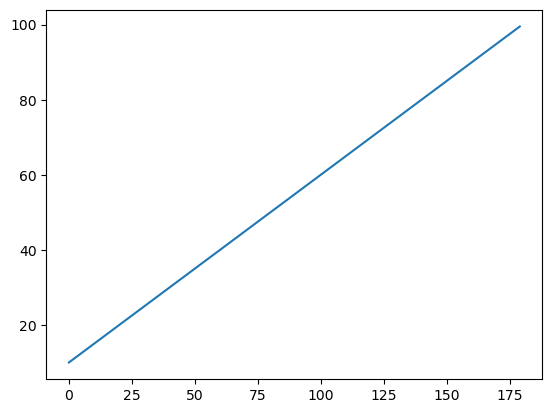

In [145]:
plt.plot(np.arange(10, 100, 0.5))
plt.show()

In [147]:
a = np.linspace(0, 10, 5)
a

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

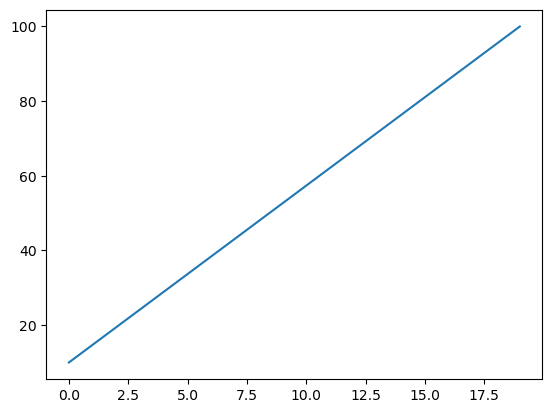

In [148]:
plt.plot(np.linspace(10, 100, 20))
plt.show()

In [ ]:
np.arange(20, 10, -.5)

In [ ]:
a = np.linspace(0, 50, 5)
a

[  1.           1.27427499   1.62377674   2.06913808   2.6366509
   3.35981829   4.2813324    5.45559478   6.95192796   8.8586679
  11.28837892  14.38449888  18.32980711  23.35721469  29.76351442
  37.92690191  48.32930239  61.58482111  78.47599704 100.        ]


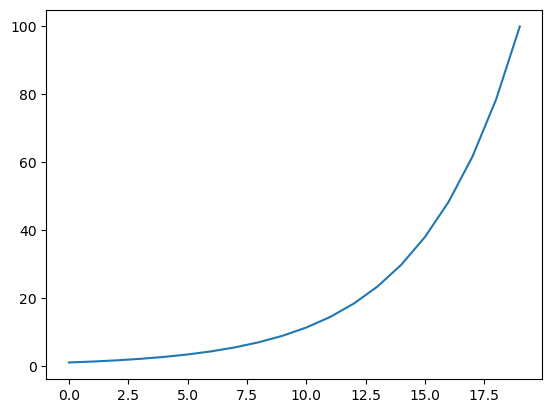

In [149]:
a = np.geomspace(1, 100, 20)
print(a)
plt.plot(a)
plt.show()

In [150]:
import torch

t1 = torch.arange(10, 20, 0.5)
print(t1)

t2 = torch.linspace(10, 20, 5)
print(t2)

t3 = torch.logspace(0, 1, 5)
t3

tensor([10.0000, 10.5000, 11.0000, 11.5000, 12.0000, 12.5000, 13.0000, 13.5000,
        14.0000, 14.5000, 15.0000, 15.5000, 16.0000, 16.5000, 17.0000, 17.5000,
        18.0000, 18.5000, 19.0000, 19.5000])
tensor([10.0000, 12.5000, 15.0000, 17.5000, 20.0000])


tensor([ 1.0000,  1.7783,  3.1623,  5.6234, 10.0000])

In [ ]:
a = np.geomspace(1, 10, 10)
a

In [ ]:
a = np.arange(1, 101).reshape((10, 10))
a

In [153]:
np.random.default_rng()

Generator(PCG64) at 0x107EAA5E0

In [155]:
np.random.seed(42)
#np.random.default_rng(42)
np.random.randn(2, 3, 4)

array([[[ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986],
        [-0.23415337, -0.23413696,  1.57921282,  0.76743473],
        [-0.46947439,  0.54256004, -0.46341769, -0.46572975]],

       [[ 0.24196227, -1.91328024, -1.72491783, -0.56228753],
        [-1.01283112,  0.31424733, -0.90802408, -1.4123037 ],
        [ 1.46564877, -0.2257763 ,  0.0675282 , -1.42474819]]])

In [ ]:

a = np.random.randn?
a

In [156]:
a = np.random.randn(10)
a

array([-0.54438272,  0.11092259, -1.15099358,  0.37569802, -0.60063869,
       -0.29169375, -0.60170661,  1.85227818, -0.01349722, -1.05771093])

In [ ]:
np.random.default_rng()

In [ ]:
np.random.default_rng()
a = np.random.randn(10)
a

In [ ]:
np.random.randn(4, 3, 2)

In [157]:
np.random.randint(10)

2

In [164]:
np.random.randint(10, 20)

15

In [ ]:
np.random.randint(10, 20)

In [165]:
np.random.randint(10, 20, 10)  # start, stop, n_items

array([15, 19, 13, 15, 11, 19, 11, 19, 13, 17])

In [ ]:
np.random.randn(4, 3)

In [ ]:
print(dir(np.random))

In [168]:
a = np.zeros((3, 3), dtype=np.int8)
a

array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]], dtype=int8)

In [167]:
a = np.ones((3, 3))
a

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [ ]:
a = np.ones((3, 3), dtype=np.uint8)
a

In [169]:
np.full((3, 3), 51)

array([[51, 51, 51],
       [51, 51, 51],
       [51, 51, 51]])

In [172]:
a = np.arange(25).reshape(5, 5)
b = np.ones(shape=a.shape, like=a, dtype=a.dtype)
print(a.dtype, b.dtype)
print(a, b, sep="\n")

int64 int64
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


In [170]:
np.empty((3, 3))  # Returns an array with "uninitialized" data.

array([[2.5e-322, 2.5e-322, 2.5e-322],
       [2.5e-322, 2.5e-322, 2.5e-322],
       [2.5e-322, 2.5e-322, 2.5e-322]])

In [173]:
%timeit np.zeros((1000, 1000))

389 μs ± 3.35 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [174]:
%timeit np.empty((1000, 1000))

18.6 μs ± 109 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [ ]:
np.empty((3, 3)) # Returns an array with "uninitialized" data.

In [185]:
np.eye(8, k=3)

array([[0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

In [179]:
np.eye(8, 3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [181]:
np.identity(8)

array([[1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1.]])

In [189]:
a = np.arange(100, 125).reshape(5, 5)
print(a)
print(np.tril(a))
print(np.triu(a))

[[100 101 102 103 104]
 [105 106 107 108 109]
 [110 111 112 113 114]
 [115 116 117 118 119]
 [120 121 122 123 124]]
[[100   0   0   0   0]
 [105 106   0   0   0]
 [110 111 112   0   0]
 [115 116 117 118   0]
 [120 121 122 123 124]]
[[100 101 102 103 104]
 [  0 106 107 108 109]
 [  0   0 112 113 114]
 [  0   0   0 118 119]
 [  0   0   0   0 124]]


In [ ]:
a = np.arange(25).reshape(5, 5)
np.tril(a, 2)

In [ ]:
a = np.arange(25).reshape(5, 5)
np.triu(a, 2)

In [190]:
np.diag([11, 35, 23, 17, 55, 64, 23, 45])

array([[11,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 35,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 23,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 17,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 55,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 64,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 23,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 45]])

In [193]:
np.vander(np.arange(5), increasing=True)

array([[  1,   0,   0,   0,   0],
       [  1,   1,   1,   1,   1],
       [  1,   2,   4,   8,  16],
       [  1,   3,   9,  27,  81],
       [  1,   4,  16,  64, 256]])

In [194]:
np.vander([2, 3, 5], 8, increasing=True)

array([[    1,     2,     4,     8,    16,    32,    64,   128],
       [    1,     3,     9,    27,    81,   243,   729,  2187],
       [    1,     5,    25,   125,   625,  3125, 15625, 78125]])

In [ ]:
len(dir(np))

In [ ]:
len(dir(torch))

In [ ]:
len(dir(a))

In [ ]:
len(dir(t))

In [197]:
a = np.array([11, 22, 33, 22, 55, 92, 66, 7, 43, 22, 33, 22, 66, 87])
print(a.min(), a.max())
print(a.mean(), a.std(), a.var())
print(a.sum(), a.prod())

7 92
41.5 26.446036700096617 699.3928571428571
581 -3610337695197046528


In [202]:
a = np.arange(24).reshape((6, 4))
print(a)

print(a.sum(), a.prod())
print(a.sum(axis=1), a.prod(axis=1)) # Row-wise sum and product
print(a.sum(axis=0), a.prod(axis=0)) # Column-wise sum and product

print(a.min(axis=1), a.max(axis=1)) # Row-wise min and max
print(a.min(axis=0), a.max(axis=0)) # Column-wise min and max

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]
276 0
[ 6 22 38 54 70 86] [     0    840   7920  32760  93024 212520]
[60 66 72 78] [      0  208845  665280 1514205]
[ 0  4  8 12 16 20] [ 3  7 11 15 19 23]
[0 1 2 3] [20 21 22 23]


In [204]:
a = np.arange(10)
print(a)

print(a.cumsum())

[0 1 2 3 4 5 6 7 8 9]
[ 0  1  3  6 10 15 21 28 36 45]


In [205]:
a = torch.tensor([11, 22, 33, 92, 22, 55, 10, 66, 43, 3, 22, 33, 22, 66, 87], dtype=torch.float32)
print(a.min(), a.max())
print(a.mean(), a.std(), a.var())
print(a.sum(), a.prod())

tensor(3.) tensor(92.)
tensor(39.1333) tensor(28.0201) tensor(785.1238)
tensor(587.) tensor(6.9416e+21)


In [206]:
print(a)
print(a.min(), a.argmin())
print(a.max(), a.argmax())

tensor([11., 22., 33., 92., 22., 55., 10., 66., 43.,  3., 22., 33., 22., 66.,
        87.])
tensor(3.) tensor(9)
tensor(92.) tensor(3)


##### Reading from disk

In [207]:
a = np.loadtxt("simple.csv", delimiter=",", skiprows=1, dtype=np.uint8)
a

array([[0, 0],
       [1, 1],
       [2, 4],
       [3, 9]], dtype=uint8)

In [ ]:
np.loadtxt("testdata.csv", skiprows=1, delimiter=',', dtype=np.uint8)

In [ ]:
a = np.arange(65, 65+25, dtype=np.uint8).reshape(5, 5)
print(a, a.dtype)


In [208]:
a = np.arange(65, 89).reshape((2, 3, 4))
print(a)


[[[65 66 67 68]
  [69 70 71 72]
  [73 74 75 76]]

 [[77 78 79 80]
  [81 82 83 84]
  [85 86 87 88]]]


In [209]:
a.tofile("testdata3.dat")

In [ ]:
a.tofile("testdata2.dat")

In [213]:
b = np.fromfile("testdata3.dat", dtype=np.uint64).reshape((2, 3, 4))
b

array([[[65, 66, 67, 68],
        [69, 70, 71, 72],
        [73, 74, 75, 76]],

       [[77, 78, 79, 80],
        [81, 82, 83, 84],
        [85, 86, 87, 88]]], dtype=uint64)

In [215]:
print(a)
print(a.dtype, a.shape)

[[[65 66 67 68]
  [69 70 71 72]
  [73 74 75 76]]

 [[77 78 79 80]
  [81 82 83 84]
  [85 86 87 88]]]
int64 (2, 3, 4)


In [216]:
import pickle

with open("testdata3.pkl", "wb") as outs:
    pickle.dump(a, outs)

In [218]:
with open("testdata3.pkl", "rb") as ins:
    p = pickle.load(ins)

print(p)
print(p.dtype, p.shape)

[[[65 66 67 68]
  [69 70 71 72]
  [73 74 75 76]]

 [[77 78 79 80]
  [81 82 83 84]
  [85 86 87 88]]]
int64 (2, 3, 4)


In [ ]:
a = np.arange(25).reshape(5, 5)
a

In [ ]:
a.tofile("nums.dat")

In [ ]:
b = np.fromfile("nums.dat")
b.dtype

In [ ]:
b = np.fromfile("nums.dat", dtype=np.uint64).reshape(5, 5)
b

In [ ]:
t = torch.arange(65, 89).reshape((2, 3, 4))
print(t)

In [ ]:
import pickle

with open("testdata4.pkl", "wb") as outs:
    pickle.dump(t, outs)

In [ ]:
with open("testdata4.pkl", "rb") as ins:
    t5 = pickle.load(ins)

print(t5)

In [ ]:
import
with open("nums.pkl", "wb") as outs:
    pickle.dump(a, outs) pickle

In [ ]:
with open("nums.pkl", "rb") as ins:
    b1 = pickle.load(ins)

b1

In [219]:
np.save("nums.npy", a)

In [220]:
b2 = np.load("nums.npy")
b2

array([[[65, 66, 67, 68],
        [69, 70, 71, 72],
        [73, 74, 75, 76]],

       [[77, 78, 79, 80],
        [81, 82, 83, 84],
        [85, 86, 87, 88]]])

In [221]:
a = np.arange(100_000)
np.save("a.npy", a)
np.savez_compressed("a.npz", a)

In [ ]:
b = np.load("a.npy")
print(b.dtype, b.size)

In [ ]:
a = np.arange(25).reshape(5, 5)
a.tolist()

In [ ]:
a.tobytes()

In [222]:
b = np.load("a.npz")
print(b)
print(b.files)
print(b.items())
c = b["arr_0"]
print(c, c.dtype, c.size)

NpzFile 'a.npz' with keys: arr_0
['arr_0']
ItemsView(NpzFile 'a.npz' with keys: arr_0)
[    0     1     2 ... 99997 99998 99999] int64 100000


In [ ]:
a = np.arange(65, 65+25).reshape(5, 5)
print(a, a.dtype)
a.tofile("testdata.dat", sep=", ")

In [ ]:
a = np.fromfile("testdata.dat")
a

In [ ]:
a = np.fromfile("testdata.dat", dtype=np.int64).reshape(5, 5)
a

In [ ]:
a = np.fromfile("testdata.dat", dtype=np.uint64)
a

In [ ]:
a = np.fromfile("testdata.dat", dtype=np.uint64).reshape(5, 5)
a

In [ ]:
a = np.arange(25).reshape(5, 5)
a.tofile("testdata2.dat", sep=",")

In [ ]:
%%timeit
a = np.array([ 0 for i in range(100)])
a

In [ ]:
%%timeit
a = np.zeros(100, dtype=np.int64)
a

In [ ]:
%%timeit
a = np.empty(100, dtype=np.int64)
a

In [ ]:
%timeit np.zeros(1_000_000)
%timeit np.empty(1_000_000)

In [ ]:
np.ones(10)

In [ ]:
np.eye(4)

In [ ]:
np.diag([1, 2, 3, 4, 5])

In [ ]:
# Vandermonde matrix
np.vander([1, 2, 3, 4])

In [ ]:
np.vander([2], 10)

In [ ]:
np.vander([2], 10, increasing=True)

In [ ]:
np.zeros((10, 10))

In [ ]:
np.empty((4, 5))

### Creating PyTorch tensors using various techniques

In [ ]:
import torch

t = torch.tensor([[10, 20, 30], [40, 50, 60]]) # From nested lists
print(t, type(t))

t = torch.arange(10, 20, 2) # From range
print(t, type(t))

t = torch.linspace(10, 20, 5) # From linspace
print(t, type(t))
t = torch.logspace(10, 20, 5) # From logspace
print(t, type(t))

t = torch.randn(4, 3) # From random normal distribution
print(t, type(t))

t = torch.randint(10, 20, (4, 3)) # From random integers
print(t, type(t))

t = torch.zeros((3, 3)) # From zeros
print(t, type(t))
t = torch.ones((3, 3))  # From ones
print(t, type(t))
t = torch.eye(5)        # From identity matrix
print(t, type(t))
t = torch.full((3, 3), 7) # From full
print(t, type(t))
t = torch.empty((3, 3))  # From empty (uninitialized)
print(t, type(t))

a = np.arange(25).reshape(5, 5)
b = torch.ones_like(torch.tensor(a))
print(b.dtype)
print(a, b, sep="\n")

a = np.arange(25).reshape(5, 5)
b = torch.zeros_like(torch.tensor(a))
print(b.dtype)
print(a, b, sep="\n")


In [ ]:
# A tensor representing scalar value
t = torch.tensor(10) 
print(t, t.ndim, t.shape, t.dtype)
print(t.size(), t.item(), t.numel())
print()

# A tensor representing 1D array (vector)
t = torch.tensor([10, 20, 30, 40, 50]) 
print(t, t.ndim, t.shape, t.dtype)
print(t.size(), t.tolist(), t.numel())
print()

# A tensor representing 2D array (matrix)
t = torch.tensor([[10, 20, 30], [40, 50, 60]]) 
print(t, t.ndim, t.shape, t.dtype)
print(t.size(), t.tolist(), t.numel())
print()

# A tensor representing 3D array (tensor)
t = torch.tensor([[[10, 20], [30, 40]], 
                  [[50, 60], [70, 80]], 
                  [[90, 100], [110, 120]]]) 
print(t, t.ndim, t.shape, t.dtype)
print(t.size(), t.tolist(), t.numel())
print()

#### Converting between pytorch tensors and numpy arrays

In [ ]:
a = np.arange(10, 20, 2)
t = torch.tensor(a)
print(a, type(a))
print(t, type(t))

a[0] = 99
print(a, type(a))
print(t, type(t))  # Note that data is copied, not shared

In [ ]:
a = np.arange(10, 20, 2)
t = torch.from_numpy(a)
print(a, type(a))
print(t, type(t))

a[0] = 99
print(a, type(a))
print(t, type(t))  # Note that data is shared between numpy array and torch tensor

In [ ]:
t = torch.arange(10, 20, 2)
a = np.array(t)  # Converting torch tensor to numpy array - deprecated way
print(t)
print(a)
print()

t[0] = 99
print(t)
print(a)  # Note that data is shared between torch tensor and numpy array

In [ ]:
t = torch.arange(10, 20, 2)
a = t.numpy()
print(t)
print(a)

a[0] = 99
print(t)
print(a)  # Note that data is shared between torch tensor and numpy array

In [ ]:
t = torch.arange(10, 20, 2)
a = t.numpy().copy()  # Creating a copy of numpy array - the correct way
print(t)
print(a)
print()

a[0] = 99
print(t)
print(a)  # Note that data is not shared anymore

### GPU acceleration in PyTorch tensors

In [ ]:
torch.accelerator.is_available() # Modern approach to check for hardware acceleration support in PyTorch

True

In [ ]:
if torch.cuda.is_available(): # Old way to check for accelerator support in PyTorch (< 2.7)
    print("CUDA is available. You can use GPU for computations.")
elif torch.mps.is_available():
    print("Metal Performance Shaders (MPS) is available. You can use Apple GPU for computations.")
else:
    print("No GPU available. You will be using CPU for computations.")

Metal Performance Shaders (MPS) is available. You can use Apple GPU for computations.


In [230]:
dev = torch.accelerator.current_accelerator() # Modern approach to check which accelerator is currently being used in PyTorch

print(f"Current accelerator: {dev}")
print(f"String name of the device: {dev.type}")


Current accelerator: mps
String name of the device: mps


In [231]:
dev = torch.accelerator.current_accelerator() \
     if torch.accelerator.is_available() else "cpu"
print(f"Using device: {dev}")

Using device: mps


In [232]:
t = torch.tensor([10, 20, 30])
print(t)
r = t + 2
print(r)

tensor([10, 20, 30])
tensor([12, 22, 32])


In [237]:
import torch
t1 = torch.arange(1000, dtype=torch.uint8)
t2 = torch.arange(1000, dtype=torch.uint8, device=dev)

print(t1.device)
print(t2.device)

cpu
mps:0


In [239]:
%timeit -n1000  z1 = t1 + 2
%timeit -n1000  z2 = t2 + 2

3.34 μs ± 625 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.38 μs ± 232 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
t1 = torch.arange(10, 20, 2)
print(t1.device)

t2 = t1.to("mps") # better way: t1.to(dev)
print(f"{t1.device=}, {t2.device=}")

t3 = t2.to("cpu")
print(f"{t2.device=}, {t3.device=}")

print(t1, t2, t3, sep="\n")

t1[0] = 99
t2[0] = 88

print(t1, t2, t3, sep="\n")  


# Dont do this:
t1.to("mps") # Does not change t1's device!

# Better way:
t1 = t1.to("mps")



cpu
t1.device=device(type='cpu'), t2.device=device(type='mps', index=0)
t2.device=device(type='mps', index=0), t3.device=device(type='cpu')
tensor([10, 12, 14, 16, 18])
tensor([10, 12, 14, 16, 18], device='mps:0')
tensor([10, 12, 14, 16, 18])
tensor([99, 12, 14, 16, 18])
tensor([88, 12, 14, 16, 18], device='mps:0')
tensor([10, 12, 14, 16, 18])


In [ ]:

t4 = t2.cpu() # Alternative way to move to CPU
print(t4.device)

print(t1, t2, t3, t4, sep="\n")
print()

t1[0] += 1
print(t1, t2, t3, t4, sep="\n")

# Moving to and from devices makes copies of data

In [245]:
t = torch.tensor([10, 20, 30], device="mps")
a = t.numpy() # Fails - as tensor must be on CPU to convert to numpy array

TypeError: can't convert mps:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [246]:
t = torch.tensor([10, 20, 30], device="mps")
a = t.cpu().numpy() # Works - tensor is moved to CPU before conversion

In [ ]:
t = torch.tensor([10, 20, 30], device="mps")
a = np.array(t)  # This also fails.
print(a)

/var/folders/8r/bd41h17j3g733j4twtb7rh9c0000gn/T/ipykernel_34410/2243988596.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  a = np.array(t)


TypeError: can't convert mps:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [249]:
a = np.array([10, 20, 30, 40])
t = torch.tensor(a, device="mps") 
print(t)

tensor([10, 20, 30, 40], device='mps:0')


In [251]:
a = np.array([10, 20, 30, 40])
t = torch.from_numpy(a).to("mps") # This also works!
# torch.from_numpy() create a tensor on CPU that shared memory with numpy array.
# Then we move that tensor to MPS, which creates a copy of the data on MPS.
print(t)

tensor([10, 20, 30, 40], device='mps:0')


#### GPU management using PyTorch


In [ ]:
torch.accelerator.is_available() # PyTorch 2.7+ onwards

In [ ]:
torch.backends.mps.is_available() # Older PyTorch versions

In [ ]:
print(dir(torch.backends))

In [254]:
device = torch.accelerator.current_accelerator() # PyTorch 2.7+ onwards
print(device)

mps


In [ ]:
# Modern way to select device
device = torch.accelerator.current_accelerator() \
         if torch.accelerator.is_available() else torch.device("cpu")
print(device)


In [ ]:
# Older way to select device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

In [ ]:
torch.accelerator.device_count()

In [ ]:
torch.accelerator.current_device_index()

In [ ]:
torch.mps.is_available()

In [255]:
torch.mps.current_allocated_memory() / (1024*1024)

1.907958984375

In [256]:
torch.mps.recommended_max_memory() / (1024*1024)

18186.25

In [257]:
torch.mps.driver_allocated_memory() / (1024*1024)

66.984375

In [262]:
torch.accelerator.get_memory_info()

AttributeError: module 'torch.accelerator' has no attribute 'get_memory_info'

#### Reshaping tensors

In [ ]:
a = torch.arange(9)
print(a)
b = a.reshape(3, 3) # Can work on contiguous / noncontiguous memory, might create a copy
print(b)
c = a.view(3, 3) # Works only on contiguous memory, does not create a copy
print(c)

In [260]:
a = torch.arange(12).reshape(4, 3)
print(a, a.shape)
b = a.T  # b is a transpose of a
print(b, b.shape)
print("-" * 50)
c = a.view(12)
print(c)

#d = b.view(12) # .view() fails if the tensor is non-contiguous
#print(d)

e = b.reshape(12) # In this case, reshape copies underlying data.
print(e)

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]]) torch.Size([4, 3])
tensor([[ 0,  3,  6,  9],
        [ 1,  4,  7, 10],
        [ 2,  5,  8, 11]]) torch.Size([3, 4])
--------------------------------------------------
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
tensor([ 0,  3,  6,  9,  1,  4,  7, 10,  2,  5,  8, 11])


##### Squeeze and Unsqueeze operations

In [ ]:
a = torch.tensor([[[10, 20, 30]]])
print(a, a.shape, a[0, 0, 0])
b = a.squeeze()
print(b, b.shape, b[0])

In [ ]:
a = torch.tensor([10, 20, 30])
print(a, a.shape)
b = a.unsqueeze(dim=1)
print(b, b.shape)

In [ ]:
a = torch.arange(12).reshape(4, 3)
print(a, a.shape)

b = a.unsqueeze(dim=1)
print(b, b.shape)

In [ ]:
a = torch.tensor([10, 20, 30, 40])
a.unsqueeze(dim=1)

In [ ]:
a = torch.tensor([10, 20, 30, 40, 50])
a.view(-1, 1)

In [ ]:
print(torch.stack((a, b)))
print(torch.vstack((a, b)))
print(torch.hstack((a, b))) # Same as torch.cat((a, b))
print(torch.stack((a, b), dim=1))

#### ```tensor``` math

In [263]:
x = torch.tensor([10, 20, 30])
y = torch.tensor([40, 50, 60])
print(x + y)
print(x - y)
print(x * y)
print(x / y)
print(x // y)
print(x % y)

tensor([50, 70, 90])
tensor([-30, -30, -30])
tensor([ 400, 1000, 1800])
tensor([0.2500, 0.4000, 0.5000])
tensor([0, 0, 0])
tensor([10, 20, 30])


In [266]:
x = torch.tensor([10, 20, 30])
#y = torch.tensor(5)
y = 5
print(x + y)
print(x - y)
print(x * y)
print(x / y)
print(x // y)
print(x % y)

tensor([15, 25, 35])
tensor([ 5, 15, 25])
tensor([ 50, 100, 150])
tensor([2., 4., 6.])
tensor([2, 4, 6])
tensor([0, 0, 0])


In [264]:
x = torch.tensor([10, 20, 30, 40])
y = torch.tensor([40, 50, 60])
print(x + y)
print(x - y)
print(x * y)
print(x / y)
print(x // y)
print(x % y)

RuntimeError: The size of tensor a (4) must match the size of tensor b (3) at non-singleton dimension 0

In [269]:
t = torch.arange(24).reshape(6, 4)
print(t)

print(t**2)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]])
tensor([[  0,   1,   4,   9],
        [ 16,  25,  36,  49],
        [ 64,  81, 100, 121],
        [144, 169, 196, 225],
        [256, 289, 324, 361],
        [400, 441, 484, 529]])


In [270]:
t = torch.arange(24).reshape(6, 4)
print(t)

x = torch.tensor([10, 20, 30, 40])
print(t + x)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]])
tensor([[10, 21, 32, 43],
        [14, 25, 36, 47],
        [18, 29, 40, 51],
        [22, 33, 44, 55],
        [26, 37, 48, 59],
        [30, 41, 52, 63]])


In [274]:
t = torch.arange(24).reshape(6, 4)
print(t)

x = torch.tensor([10, 20, 30, 40, 50, 60]).reshape(-1, 1)
print(x)

print("-" * 50)
print(t + x)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]])
tensor([[10],
        [20],
        [30],
        [40],
        [50],
        [60]])
--------------------------------------------------
tensor([[10, 11, 12, 13],
        [24, 25, 26, 27],
        [38, 39, 40, 41],
        [52, 53, 54, 55],
        [66, 67, 68, 69],
        [80, 81, 82, 83]])


#### Broadcasting arithmetic operations

In [ ]:
a = torch.arange(25).reshape(5, 5)

print(a)
print()

a += 10

print(a)

In [ ]:
a = torch.arange(25).reshape(5, 5)

print(a)
print()

a[:, 1] += 10

print(a)

In [ ]:
a = torch.tensor([10, 20, 30, 40])
b = torch.tensor([11, 22, 33, 44])

print(a + b)

In [ ]:
a = torch.tensor([10, 20, 30, 40, 50, 60])
print(a + 1)
print(a - 1)
print(a * 2)
print(a ** 2)

In [ ]:
a = torch.tensor([10, 20, 30, 40])
b = torch.tensor([11, 22, 33, 44])
print(a.shape, b.shape)

c = a + b  # + performs element-wise addition, not "concatenation"
print(c)
print(b - a)
print(a * b)


In [ ]:
a = torch.tensor([10, 20, 30, 40])
b = torch.tensor([11, 22, 33, 44])
print(a.shape, b.shape)

c = a + b  # + performs element-wise addition, not "concatenation"
print(c)
print(b - a)
print(a * b)


In [ ]:
a = torch.arange(25).reshape(5, 5)
print(a)

In [ ]:
b = torch.arange(5)
b

In [ ]:
print(a)

In [ ]:
a + b

In [ ]:
a = torch.arange(5)
print(a, a.shape)

b = a.reshape(-1, 1)
print(b, b.shape)

c = a + b
print(c)

NOTE:
For most binary arithmetic (+, -, *, /, **, //): if one of the operand is a number, the operation is applied for all elements in the numpy array (element-wise broadcasting of operations)

However, if both operands are numpy arrays, the first ranks in their shape must be indentical.

<div style="background-color: white; padding: 10px;">
   <img src="./broadcasting_1.png" alt="1-d broadcasting">
</div>

<div style="background-color: white; padding: 10px;">
   <img src="./broadcasting_2.png" alt="2-d broadcasting">
</div>

<div style="background-color: white; padding: 10px;">
   <img src="./broadcasting_3.png" alt="Broadcast mismatch">
</div>

<div style="background-color: white; padding: 10px;">
   <img src="./broadcasting_4.png" alt="Stretching while 2-d broadcasting">
</div>

In [ ]:
a = torch.tensor([10, 20, 30, 40, 50])
b = torch.tensor([11, 22, 33, 44, 55])

print(a + b)

In [ ]:
a = torch.arange(25).reshape(5, 5)
b = torch.tensor([10, 20, 30, 40, 50])
print(a, b, sep="\n\n")
print()
print(a + b)

In [ ]:
a = torch.arange(25).reshape(5, 5)
b = torch.tensor([10, 20, 30, 40, 50]).reshape(-1, 1)
print(a.shape, b.shape)
print(a, b, sep="\n\n")
print()
print(a + b)

In [ ]:
a = torch.arange(25).reshape(5, 5)
b = torch.full((5, 1), 5)
print(a.shape, b.shape)
print(a, b, sep="\n\n")
print()
print(a + b)

In [ ]:
a = np.full(25, 3).reshape(5, 5)
b = np.full(25, 2).reshape(5, 5)

c = a * b

print(a, b, c, sep="\n\n")

In [ ]:
a = np.full(25, 3).reshape(5, 5)
b = np.full(25, 2).reshape(5, 5)

#c = a.dot(b)
c = a @ b
print(a, b, c, sep="\n\n")

In [278]:
t1 = torch.tensor([10, 20, 30, 40], device=dev)
t2 = torch.tensor([11, 22, 33, 44])
print(t1.device, t2.device)
print(t1 + t2.to(dev))
print(t1.cpu() + t2)

mps:0 cpu
tensor([21, 42, 63, 84], device='mps:0')
tensor([21, 42, 63, 84])


In [279]:
t1 = torch.tensor([10, 20, 30, 40])
t2 = torch.tensor([11, 22, 33, 44])
t1 + t2

tensor([21, 42, 63, 84])

In [280]:
torch.concat((t1, t2))

tensor([10, 20, 30, 40, 11, 22, 33, 44])

In [281]:
t1 = torch.arange(25).reshape(5, 5)
t2 = torch.arange(100, 125).reshape(5, 5)

torch.concat((t1, t2)) # Concatenate along rows (vertical stack)

tensor([[  0,   1,   2,   3,   4],
        [  5,   6,   7,   8,   9],
        [ 10,  11,  12,  13,  14],
        [ 15,  16,  17,  18,  19],
        [ 20,  21,  22,  23,  24],
        [100, 101, 102, 103, 104],
        [105, 106, 107, 108, 109],
        [110, 111, 112, 113, 114],
        [115, 116, 117, 118, 119],
        [120, 121, 122, 123, 124]])

In [282]:
t1 = torch.arange(25).reshape(5, 5)
t2 = torch.arange(100, 125).reshape(5, 5)

torch.concat((t1, t2), dim=1) # Concatenate along columns (horizontal stack)

tensor([[  0,   1,   2,   3,   4, 100, 101, 102, 103, 104],
        [  5,   6,   7,   8,   9, 105, 106, 107, 108, 109],
        [ 10,  11,  12,  13,  14, 110, 111, 112, 113, 114],
        [ 15,  16,  17,  18,  19, 115, 116, 117, 118, 119],
        [ 20,  21,  22,  23,  24, 120, 121, 122, 123, 124]])

#### Mutation operations on tensors

In [ ]:
a = torch.tensor([10, 20, 30, 40, 50, 60])
a

In [ ]:
a[0] = 100
print(a)

In [ ]:
a[:3] = 0
print(a)

In [ ]:
a = torch.arange(100).reshape(10, 10)
print(a)

In [ ]:
a[3:7, 3:7] = 0
print(a)

In [ ]:
a[::2] = 0
print(a)

In [ ]:
torch.random.manual_seed(42)    
a = torch.randint(10, 100, (15,))
a

In [ ]:
b = a > 50
print(b, b.dtype)

In [ ]:
x = torch.arange(9).reshape(3, 3)
y  = torch.arange(1, 4).unsqueeze(dim=1)
print(x, y, sep="\n")

y1 = torch.arange(1, 4)
print(y1)

z = x @ y # x.dot(y), torch.dot(x, y)
print(z)

print(x @ y1)

In [ ]:
# Element-wise (broadcast operations)
print(x)
print(x + 1)
print(x * 2)
print(x ** 2)

In [ ]:
t1 = torch.tensor([10, 20, 30])
t2 = torch.tensor([11, 22, 33], device="mps")

t3 = t1 + t2
print(t3)

In [ ]:
t1 = torch.tensor([10, 20, 30], device="mps")
t2 = torch.tensor([11, 22, 33], device="mps")

t3 = t1 + t2
print(t3)

In [ ]:
a = torch.tensor([2, 5, 3])
b = torch.tensor([4, 5, 6]).reshape(3, 1)
print(a)
print(b)
a + b

In [ ]:
z = torch.add(x, y)
z

In [ ]:
a = torch.tensor([10, 20])
print(a.add(5))  # a + 5
print(a.mul(3))  # a * 3
print(a)

In [ ]:
a = torch.tensor([10, 20])
print(a.add_(5))  # a += 5
print(a)

b = a.add_(5)   # b = a += 5
print(a, b)

In [ ]:
a = torch.tensor([10, 20])
a += 5
print(a)

In [ ]:
a = torch.tensor([10, 20])
b = a += 5 # This wont work - Python syntax does not allow this

In [ ]:
y.add_(x)  # all methods ending with _ performs in-place operation
y

In [ ]:
z = x - y
print(z)
z = torch.sub(x, y)
print(z)

In [ ]:
z = torch.mul(x, y)
print(z)

In [ ]:
x = torch.arange(12).reshape(3, 4)
x[1, 1]

In [ ]:
x[1, 1].item()

In [ ]:
y = x.view(12)
y

In [ ]:
x = torch.rand(4, 4)
print(x.shape)
y = x.view(-1, 8)
print(y.shape)

##### Slicing / Dicing with numpy arrays / pytorch tensors

In [ ]:
a = torch.arange(25)
print(a)
print(a[:5], a[-5:], a[3:7])
print(a[::2])

In [ ]:
a = torch.arange(10)
print(a)
print(a[:3])

a[:3] = 10
print(a)

In [ ]:
a = torch.arange(25).reshape(5, 5)
print(a)
a[1, 1]

In [ ]:
a = torch.arange(25).reshape(5, 5)
print(a)
a[:3, 1]

In [ ]:
a[:3, :3]

In [ ]:
a[:, ::2]

In [ ]:
a[::2, :]

In [ ]:
print(a)
print(a[1:4, 1:4])

##### Interesting slicing use-case

In [ ]:
a = torch.tensor([1, 2, 3, 4, 5, 6])
print(a, a.shape)

print(a.reshape(2, 3))
print(a.reshape(1, 6))
b = a.reshape(1, -1)
print(b, b.shape)

In [ ]:
a = torch.arange(24)
a

In [ ]:
a.reshape(4, -1)  # Same as a.reshape(4, 6)

In [ ]:
a.reshape(-1, 4)

In [ ]:
a.reshape(2, -1, 4)

In [ ]:
a = torch.arange(25).reshape(5, 5)
print(a)
a[:3, :3]

In [ ]:
a = torch.arange(100).reshape(10, 10)
print(a)
a[:5, :5]

In [ ]:
a = torch.arange(100).reshape(10, 10)
print(a)
a[:5:2, :5:2]

In [ ]:
a = torch.arange(100).reshape(10, 10)
print(a)
a[::2, ::2]

In [ ]:
a = torch.arange(100).reshape(10, 10)
print(a[:, 3])
print(a[3])

In [ ]:
a = torch.arange(100).reshape(10, 10)
#b = a[:, 3].reshape(10, 1)
b = a[:, 3].reshape(-1, 1)
print(b, b.shape)

In [ ]:
a = torch.arange(100).reshape(10, 10)
b = a[:, 3:5]
print(b, b.shape)

In [ ]:
a = torch.arange(100).reshape(10, 10)
print(a)
a[:, 3] = 0
print(a)

In [ ]:
a = torch.arange(25).reshape(5, 5)
b = a + 10

print(a, b, sep="\n\n")

In [ ]:
a = torch.arange(25).reshape(5, 5)

print(a)
print()

a += 10

print(a)

In [ ]:
a = torch.tensor([10, 20, 30, 40])
b = torch.tensor([11, 22, 33, 44])

print(a + b)

In [ ]:
a = torch.tensor([10, 20, 30, 40, 50, 60])
print(a + 1)
print(a - 1)
print(a * 2)
print(a ** 2)

In [ ]:
a = torch.tensor([10, 20, 30, 40])
b = torch.tensor([11, 22, 33, 44])
print(a.shape, b.shape)

c = a + b  # + performs element-wise addition, not "concatenation"
print(c)
print(b - a)
print(a * b)


In [ ]:
a = torch.arange(25).reshape(5, 5)
print(a)

In [ ]:
b = torch.arange(5)
b

In [ ]:
print(b.shape)
b = b.reshape(-1, 1)
print(b.shape)
print(b)

In [ ]:
print(a)

In [ ]:
a + b

In [ ]:
a = torch.arange(5)
print(a, a.shape)

b = a.reshape(-1, 1)
print(b, b.shape)

c = a + b
print(c)

### Filtering operations

In [ ]:
a = torch.tensor([22, 55, 77, 11, 22, 88])
print(a)
print(a[[3, 0, 2, 4]]) # Subscripting using a list-of-indices

print(a[[True, False, False, True, False, True]]) # Subscripting using a list-of-booleans

In [ ]:
np.random.seed(42)
a = np.random.randint(10, 100, 15)
a

In [ ]:
b = a > 50  # Comparison is applied element-wise returning an array of booleans
print(b, b.dtype)

In [ ]:
print(a)
print(a[a > 50]) # Extracts all items that are greater than 50 (a filter operation)

In [ ]:
a[a % 2 == 1]

In [ ]:
print(a)
a[a > 50] = 0
print(a)

In [ ]:
a = [10, 20, 30, 40, 50, 60, 70, 80]
a[:3] = [0] * 3
a

In [ ]:
a = [10, 20, 30, 40, 50, 60, 70, 80, 90]
a[:5:2]

In [ ]:
a = np.arange(25).reshape(5,5)
#b1 = np.full(5, 10)
b1 = np.array([2, 5, 3, 1, 4])
b2 = b1.reshape(-1, 1)

print(a, b1, b2, sep="\n\n")
print("a - b1:", a-b1, sep="\n\n")
print("a - b2:", a-b2, sep="\n\n")

In [ ]:
# To select a subset of items from a numpy array, you can pass a list of indices of choice
# Filter based on list of indices
a = np.array([14, 78, 12, 13, 89, 15, 62, 67, 19, 27, 33, 30, 16])
a[[4, 2, -4, 5]]


In [ ]:
# To select a subset of items from a numpy array, you can pass a list of booleans
# Filter based on criteria
a = np.array([14, 78, 12, 13])
print(a)
a[[True, False, False, True]]

In [ ]:
a = np.array([14, 78, 12, 13, 89, 15, 62, 67, 19, 27, 33, 30, 16])

a < 20

In [ ]:
a = np.array([14, 78, 12, 13, 89, 15, 62, 67, 19, 27, 33, 30, 16])

a[a < 20]

In [ ]:
a = np.array([14, 78, 12, 13, 89, 15, 62, 67, 19, 27, 33, 30, 16])

print(a[a % 2 != 0])

print(a & 1)
print(a[a & 1])
print(a[a & 1 == 0])

In [ ]:
a = torch.tensor([14, 78, 12, 13, 89, 15, 62, 67, 19, 27, 33, 30, 16])

print(a[a % 2 != 0])

print(a & 1)
print(a[a & 1])
print(a[a & 1 == 0])

In [ ]:
x = torch.tensor([14, 78, 12, 13, 89, 15, 62, 67, 19, 27, 33, 30, 16])
y = torch.where(x > 50, x, 0)
y

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch

In [ ]:
# Implementing ReLU using torch.where
x = torch.arange(-10, 10)
y = x.where(x >= 0, 0)
y

plt.plot(x.numpy(), y.numpy())
plt.title("ReLU Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.show()

In [ ]:
# Implementing LeakyReLU using torch.where
x = torch.arange(-10, 10)
alpha = 0.02
y = x.where(x >= 0, alpha * x)
y

plt.plot(x.numpy(), y.numpy())
plt.title("Leaky ReLU Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.show()

In [ ]:
# Implementing tanh manually

x = torch.linspace(-5, 5, 200)

# Implement tanh manually using its mathematical definition
# tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))
# The output naturally saturates between `-1` and `+1`, 
# which makes `tanh` useful for centering activations around zero.
y = (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

# Plot the tanh function
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='tanh(x)', color='teal', linewidth=2)

# Add axis lines and labels
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Tanh Activation Function', fontsize=14)
plt.xlabel('Input', fontsize=12)
plt.ylabel('Output', fontsize=12)
plt.ylim(-1.2, 1.2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


In [ ]:
# Implementing Sigmoid manually

import torch
import matplotlib.pyplot as plt

# Create input tensor
x = torch.linspace(-10, 10, 400)

# Implement sigmoid manually using its mathematical definition
# sigmoid(x) = 1 / (1 + e^(-x))
y = 1 / (1 + torch.exp(-x))

# Plot the sigmoid function
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='sigmoid(x)', color='purple', linewidth=2)
# Add axis lines and labels
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Sigmoid Activation Function', fontsize=14)
plt.xlabel('Input', fontsize=12)
plt.ylabel('Output', fontsize=12)
plt.ylim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# Comparing Sigmoid / Tanh manually

import torch
import matplotlib.pyplot as plt

# Create input tensor
x = torch.linspace(-10, 10, 400)

# Implement sigmoid manually using its mathematical definition
# sigmoid(x) = 1 / (1 + e^(-x))
sigmoid_y = 1 / (1 + torch.exp(-x))

# Implement tanh manually using its mathematical definition
# tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))
tanh_y = (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))


# Plot the sigmoid function
plt.figure(figsize=(8, 5))
plt.plot(x, sigmoid_y, label='sigmoid(x)', color='purple', linewidth=2)
plt.plot(x, tanh_y, label='tanh(x)', color='teal', linewidth=2)
# Add axis lines and labels
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Sigmoid and Tanh Activation Functions', fontsize=14)
plt.xlabel('Input', fontsize=12)
plt.ylabel('Output', fontsize=12)
plt.ylim(-1.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# Implementing Softmax manually

# Define a wider input range for better visualization
x = torch.linspace(-5, 5, 200)

# Compute softmax for 3 "classes" by shifting x differently
logits = torch.stack([x, x - 2, x + 2])  # simulate 3 different neurons
exp_logits = torch.exp(logits)
softmax_vals = exp_logits / torch.sum(exp_logits, dim=0, keepdim=True)

# Plot softmax probabilities
plt.figure(figsize=(8, 5))

plt.plot(x, softmax_vals[0], label='Class 1', linewidth=2)
plt.plot(x, softmax_vals[1], label='Class 2', linewidth=2)
plt.plot(x, softmax_vals[2], label='Class 3', linewidth=2)

plt.title('Softmax Activation for 3 Classes', fontsize=14)
plt.xlabel('Input (logit value)', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


NOTE: The above activation functions (and many more...) are already implemented in PyTorch under `torch.nn.functional` module.

### Manipulating images using `numpy`

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
img = plt.imread("face.png")

In [ ]:
img.shape

In [ ]:
plt.imshow(img)
plt.show()

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
img = Image.open('face.png')
print(img, type(img))
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')  # Hide axis
plt.show()

In [ ]:
img_array = np.array(img)
print(img_array.shape, img_array.size)
img_array

In [ ]:
img2 = img_array[200:400, 500:750, :]

In [ ]:
img2[::2, ::2, :] = 0

In [ ]:
plt.subplot(1, 2, 1)
plt.axis('off')  # Hide axis
plt.imshow(img_array)
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.axis('off')  # Hide axis
plt.imshow(img2)
plt.title("Clipped Image")
plt.imsave("face_clipped.png", img2)
plt.show()

In [ ]:

img_array = np.array(img)

y1, x1 = 100, 100  
y2, x2 = 250, 200  
cropped_img = img_array[y1:y2, x1:x2]


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title('Original Image')
plt.axis('off')

# Display the cropped image
plt.subplot(1, 2, 2)
plt.imshow(cropped_img)
plt.title('Cropped Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
img = Image.open('face.png')

img_array = np.array(img)


rotated_img = np.rot90(img_array)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title('Original Image')
plt.axis('off')

# Display the cropped image
plt.subplot(1, 2, 2)
plt.imshow(rotated_img)
plt.title('Rotated Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
a = np.arange(25).reshape(5, 5)
print(a, end="\n\n")
print(np.fliplr(a), end="\n\n")
print(np.flipud(a), end="\n\n")
print(np.rot90(a))

In [ ]:
img = Image.open('face.png')

img_array = np.array(img)


flipped_img = np.fliplr(img_array)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(flipped_img)
plt.title('Flipped Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
img = Image.open('face.png')

img_array = np.array(img)


is_grayscale = len(img_array.shape) < 3

# Function to create negative of an image
def create_negative(image):
    if is_grayscale:
        # For grayscale images
        negative_image = 255 - image
    else:
        # For color images (RGB)
        negative_image = 255 - image
    return negative_image

# Create negative of the image
negative_image = create_negative(img_array)

# negative_image = 255 - img_array

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_image)
plt.title('Negative Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
img = Image.open('face.png')

# Convert the image to grayscale
img_gray = img.convert('L')

# Convert the grayscale image to a NumPy array
img_array = np.array(img_gray)

# Binarize the image using a threshold
threshold = 128
binary_img = np.where(img_array < threshold, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_img, cmap='gray')
plt.title('Binary Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from scipy import misc
import imageio
f = misc.face()
imageio.imsave('face.png', f) # uses the Image module (PIL)

import matplotlib.pyplot as plt
plt.imshow(f)
plt.show()

In [ ]:
img = plt.imread("face.png")

In [ ]:
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
img[:, :, 0].sum()

In [ ]:
img[:, :, 1].sum()

In [ ]:
img[:, :, 2].sum()

In [ ]:
plt.imshow(img[20:100, 50:150, :])
plt.axis('off')
plt.show()

In [ ]:
img2 = img.copy()
img2[:, :, 2] += 1
plt.imshow(img2)
plt.axis('off')
plt.show()

In [ ]:
plt.imshow(img[::2, :, :])
plt.axis('off')
plt.show()

In [ ]:
img2 = img.copy()
img2[::2, :, :] = 0 
plt.imshow(img2)
plt.axis('off')
plt.show()